# Ch5 z 域(The z-Domain)

**對應原書**:Chapter 5
**軟體替代**:ModelQ 數位方塊 → `control.sample_system` 各種離散化方法比較

## 學習目標
1. 理解 $z = e^{sT}$ 的極點對應:s 左半平面 ↔ z 單位圓內。
2. 比較 ZOH、Tustin、matched 三種離散化的頻率響應差異。
3. 觀察混疊(aliasing):取樣率不足時高頻訊號偽裝成低頻。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

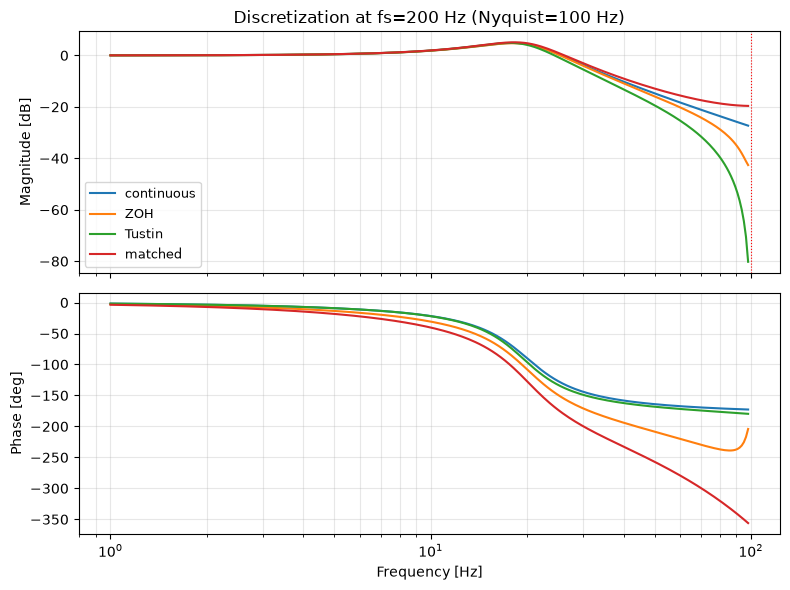

DC gains: [1. 1. 1. 1.]


In [2]:
# --- 離散化方法比較 ---
P = second_order(wn=2 * np.pi * 20, zeta=0.3)   # 20 Hz、欠阻尼
fs = 200.0
dt = 1 / fs
Pz_zoh = ct.sample_system(P, dt, method='zoh')
Pz_tus = ct.sample_system(P, dt, method='tustin')
Pz_mat = ct.sample_system(P, dt, method='matched')

f = np.logspace(0, np.log10(0.49 * fs), 300)
fig, (axm, axp) = bode_compare([
    ('continuous', P),
    ('ZOH', Pz_zoh),
    ('Tustin', Pz_tus),
    ('matched', Pz_mat),
], f_hz=f, title=f'Discretization at fs={fs:.0f} Hz (Nyquist={fs/2:.0f} Hz)')
axm.axvline(fs / 2, color='r', ls=':', lw=0.8)
plt.show()

dc = [float(ct.dcgain(s)) for s in (P, Pz_zoh, Pz_tus, Pz_mat)]
print('DC gains:', np.round(dc, 6))

## 極點對應 $z = e^{sT}$

s 平面極點 $s = -50 \pm j200$(阻尼振盪)。取樣率越低,z 極點越靠近單位圓
——同一個連續系統,取樣率低時離散模型「看起來」越接近不穩定邊緣。

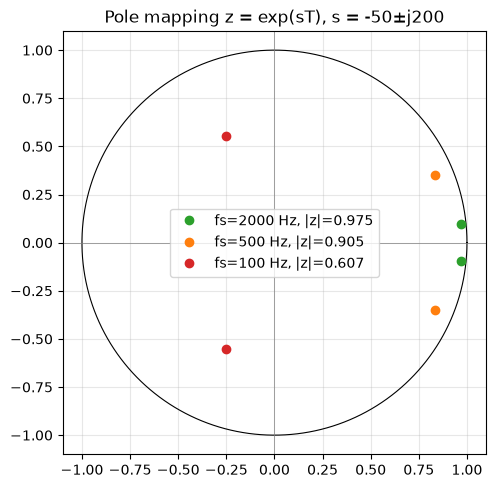

In [3]:
s_pole = -50 + 200j
fig, ax = plt.subplots(figsize=(5.5, 5.5))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), 'k-', lw=0.8)
for fs_i, c in [(2000, 'tab:green'), (500, 'tab:orange'), (100, 'tab:red')]:
    zp = np.exp(s_pole / fs_i)
    ax.plot([zp.real, zp.real], [zp.imag, -zp.imag], 'o', color=c,
            label=f'fs={fs_i} Hz, |z|={abs(zp):.3f}')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Pole mapping z = exp(sT), s = -50±j200')
plt.show()

## 混疊(Aliasing)

60 Hz 訊號用 70 Hz 取樣(低於 Nyquist 需要的 120 Hz),
取樣點看起來就是一個 $|70-60| = 10$ Hz 的訊號 —— 抗混疊濾波器存在的理由。

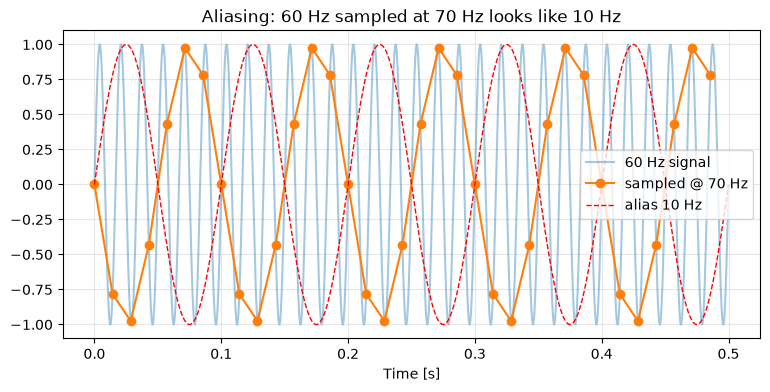

取樣點 vs 10 Hz 弦波相關係數: -1.0000


In [4]:
f_sig, fs_slow = 60.0, 70.0
t_fine = np.linspace(0, 0.5, 5000)
t_samp = np.arange(0, 0.5, 1 / fs_slow)
x_fine = np.sin(2 * np.pi * f_sig * t_fine)
x_samp = np.sin(2 * np.pi * f_sig * t_samp)
alias_f = abs(fs_slow - f_sig)

plt.figure(figsize=(9, 4))
plt.plot(t_fine, x_fine, alpha=0.4, label=f'{f_sig:.0f} Hz signal')
plt.plot(t_samp, x_samp, 'o-', label=f'sampled @ {fs_slow:.0f} Hz')
plt.plot(t_fine, np.sin(2 * np.pi * alias_f * t_fine), 'r--', lw=1,
         label=f'alias {alias_f:.0f} Hz')
plt.xlabel('Time [s]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Aliasing: 60 Hz sampled at 70 Hz looks like 10 Hz')
plt.show()

# 量化驗證:取樣點與 10 Hz 弦波(反相)的相關性
corr = np.corrcoef(x_samp, np.sin(2 * np.pi * alias_f * t_samp))[0, 1]
print(f'取樣點 vs {alias_f:.0f} Hz 弦波相關係數: {corr:.4f}')

In [5]:
# ✅ 驗證
for g in dc[1:]:
    assert abs(g - dc[0]) < 1e-6, '離散化不得改變 DC 增益'
zp = np.exp((-50 + 200j) / 100)
assert abs(zp) < 1 and abs(zp) > 0.55       # 穩定但靠近單位圓
assert abs(abs(np.corrcoef(x_samp, np.sin(2*np.pi*10*t_samp))[0,1])) > 0.99
# Tustin 在 Nyquist 附近相位比 ZOH 準(ZOH 額外半拍延遲)
d_t = frf_of_system(Pz_tus, [40.0]); d_z = frf_of_system(Pz_zoh, [40.0]); d_c = frf_of_system(P, [40.0])
assert abs(d_t['phase_deg'][0] - d_c['phase_deg'][0]) < abs(d_z['phase_deg'][0] - d_c['phase_deg'][0])
print('Ch5 驗證通過 ✅')

Ch5 驗證通過 ✅


## 練習
1. 將 fs 提高到 2 kHz 重畫離散化比較圖,三種方法還分得出差異嗎?
2. 用 `ct.sample_system` 把第 2 章的 PI 控制器離散化,比較 ZOH 與 Tustin 版的閉迴路 step response。
3. 對 130 Hz 訊號用 70 Hz 取樣,混疊頻率是多少?先算再模擬。
4. 畫出 z 平面上等阻尼比(ζ = 0.7)的軌跡(提示:s = -ζω ± jω√(1-ζ²) 掃 ω)。